In [1]:
"""
Этап 11 (бонус). Basket analysis.

Ищем товары, которые часто покупают вместе.
Используем упрощённую версию: топ-100 SKU по выручке.

Метрики:
- Support: доля заказов с товаром.
- Confidence: P(B|A).
- Lift: P(A,B) / (P(A)*P(B)).
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql, _get_conn_params

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
# Топ-100 SKU по выручке (за весь период)
top_skus = read_sql("""
    SELECT
        stock_code,
        MAX(description) AS description,
        ROUND(SUM(revenue)::numeric, 2) AS revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC
    LIMIT 100;
""")
top_skus["revenue"] = top_skus["revenue"].astype(float)
top_list = tuple(top_skus["stock_code"].tolist())
top_sql = ", ".join(f"'{c}'" for c in top_list)

print(f"Топ-100 SKU: их выручка = £{top_skus['revenue'].sum():,.2f}")

# Загружаем заказы с этими SKU
orders_with_top = read_sql(f"""
    SELECT
        invoice_no,
        stock_code
    FROM sales
    WHERE stock_code IN ({top_sql})
    GROUP BY invoice_no, stock_code;
""")
print(f"Заказов с топ-100 SKU: {orders_with_top['invoice_no'].nunique():,}")
print(f"Строк (заказ × SKU): {len(orders_with_top):,}")

Топ-100 SKU: их выручка = £5,918,824.34
Заказов с топ-100 SKU: 31,382
Строк (заказ × SKU): 160,825


In [3]:
total_orders = read_sql("SELECT COUNT(DISTINCT invoice_no) AS n FROM sales;")
total_orders = int(total_orders["n"].iloc[0])
print(f"Всего заказов в базе: {total_orders:,}")

# Support каждого топ-SKU
sku_support = (
    orders_with_top.groupby("stock_code")
    .agg(orders_with_sku=("invoice_no", "nunique"))
    .reset_index()
)
sku_support["support"] = sku_support["orders_with_sku"] / total_orders

print("Топ-20 SKU по support:")
display(sku_support.nlargest(20, "support").merge(top_skus, on="stock_code"))

Всего заказов в базе: 39,526
Топ-20 SKU по support:


,stock_code,orders_with_sku,support,description,revenue
0,85123A,5365,0.14,WHITE HANGING HEART T-LIGHT HOLDER,"263,109.67"
1,85099B,3989,0.10,RED RETROSPOT JUMBO BAG,"183,454.83"
2,22423,3918,0.10,REGENCY CAKESTAND 3 TIER,"344,563.25"
3,21212,3118,0.08,PACK OF 72 RETROSPOT CAKE CASES,"52,997.20"
4,20725,3056,0.08,LUNCH BAG RED SPOTTY,"72,292.85"
5,84879,2807,0.07,ASSORTED COLOUR BIRD ORNAMENT,"132,187.92"
6,47566,2674,0.07,PARTY BUNTING,"149,187.05"
7,21232,2435,0.06,STRAWBERRY CERAMIC TRINKET POT,"50,760.48"
8,22383,2398,0.06,LUNCHBAG SUKI DESIGN,"43,932.56"
9,20727,2351,0.06,LUNCH BAG BLACK SKULL.,"46,422.49"


In [4]:
# Self-join по invoice_no для создания пар
pairs = read_sql(f"""
    SELECT
        a.stock_code AS sku_a,
        b.stock_code AS sku_b,
        COUNT(DISTINCT a.invoice_no) AS joint_orders
    FROM sales a
    INNER JOIN sales b ON a.invoice_no = b.invoice_no
    WHERE a.stock_code IN ({top_sql})
      AND b.stock_code IN ({top_sql})
      AND a.stock_code < b.stock_code
    GROUP BY a.stock_code, b.stock_code
    HAVING COUNT(DISTINCT a.invoice_no) >= 10;
""")

print(f"Пар с ≥10 совместными заказами: {len(pairs):,}")

# Джойним support для обоих SKU
pairs = pairs.merge(
    sku_support[["stock_code", "support"]].rename(columns={
        "stock_code": "sku_a", "support": "support_a"
    }),
    on="sku_a"
)
pairs = pairs.merge(
    sku_support[["stock_code", "support"]].rename(columns={
        "stock_code": "sku_b", "support": "support_b"
    }),
    on="sku_b"
)

# Метрики
pairs["support_ab"] = pairs["joint_orders"] / total_orders
pairs["confidence_a_to_b"] = pairs["support_ab"] / pairs["support_a"]
pairs["confidence_b_to_a"] = pairs["support_ab"] / pairs["support_b"]
pairs["lift"] = pairs["support_ab"] / (pairs["support_a"] * pairs["support_b"])

print("\nТоп-20 пар по lift (при joint_orders >= 20):")
display(
    pairs[pairs["joint_orders"] >= 20]
    .nlargest(20, "lift")[[
        "sku_a", "sku_b", "joint_orders",
        "support_ab", "confidence_a_to_b", "confidence_b_to_a", "lift",
    ]]
)

Пар с ≥10 совместными заказами: 4,842

Топ-20 пар по lift (при joint_orders >= 20):


,sku_a,sku_b,joint_orders,support_ab,confidence_a_to_b,confidence_b_to_a,lift
4821,84997C,84997D,651,0.02,0.68,0.60,24.94
4814,84997B,84997C,573,0.01,0.56,0.60,23.37
98,15056BL,15056N,445,0.01,0.52,0.43,19.87
4815,84997B,84997D,537,0.01,0.53,0.49,19.20
4285,22726,22727,836,0.02,0.66,0.61,19.04
4105,22629,22630,829,0.02,0.61,0.62,17.97
3251,22188,22189,282,0.01,0.50,0.22,15.16
3415,22326,22328,566,0.01,0.41,0.49,13.88
2501,21928,21929,757,0.02,0.49,0.47,11.99
2800,22086,22910,839,0.02,0.42,0.59,11.52


In [5]:
# Проверяем: сколько кандидатов из candidates_final участвуют в парах с топ-100?
candidates_codes = read_sql("SELECT stock_code FROM candidates_final;")
candidates_set = set(candidates_codes["stock_code"].tolist())

# Пары, где один из SKU — кандидат, а второй — топ-100
risk_pairs = pairs[
    (pairs["sku_a"].isin(candidates_set) | pairs["sku_b"].isin(candidates_set))
    & (pairs["joint_orders"] >= 20)
    & (pairs["lift"] >= 1.5)
].copy()

print(f"Пары с кандидатами (lift ≥ 1.5, joint ≥ 20): {len(risk_pairs):,}")
if len(risk_pairs) > 0:
    display(
        risk_pairs.nlargest(20, "lift")[[
            "sku_a", "sku_b", "joint_orders", "lift",
            "confidence_a_to_b", "confidence_b_to_a",
        ]]
    )
else:
    print("Нет пар с сильной связью. Кандидаты не влияют на топ-корзину.")

Пары с кандидатами (lift ≥ 1.5, joint ≥ 20): 0
Нет пар с сильной связью. Кандидаты не влияют на топ-корзину.


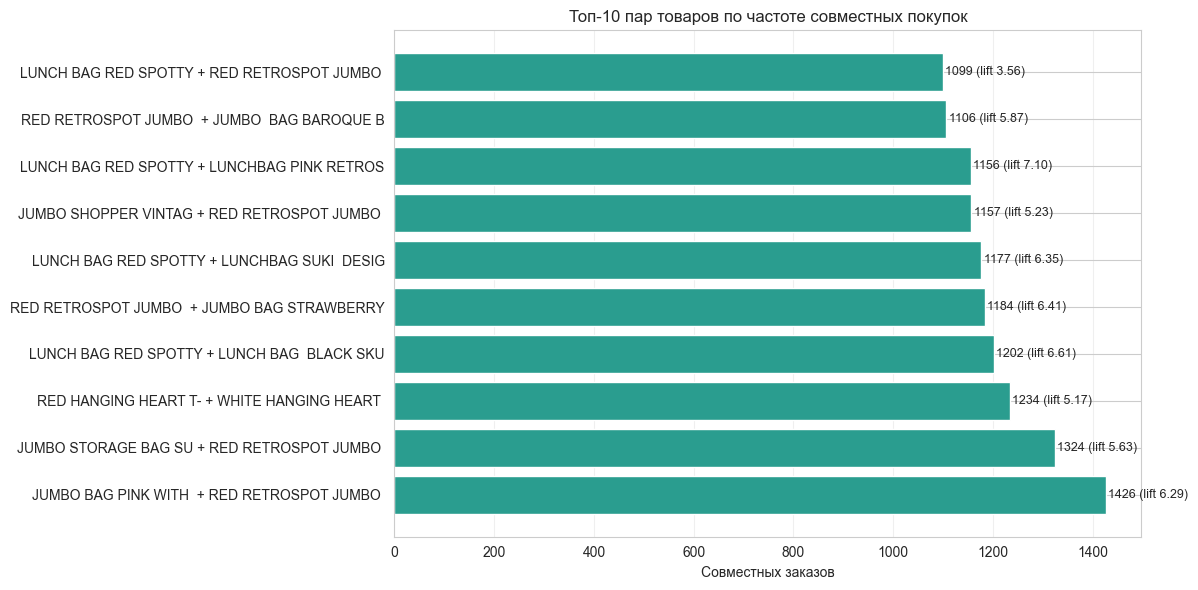

In [7]:
top_pairs = pairs.nlargest(10, "joint_orders")[[
    "sku_a", "sku_b", "joint_orders", "lift",
]]

# Джойним описания
desc = read_sql("SELECT stock_code, description FROM abc_xyz;")
desc_map = dict(zip(desc["stock_code"], desc["description"]))

top_pairs["desc_a"] = top_pairs["sku_a"].map(desc_map)
top_pairs["desc_b"] = top_pairs["sku_b"].map(desc_map)

fig, ax = plt.subplots(figsize=(12, 6))

labels = [
    f"{a[:20]} + {b[:20]}"
    for a, b in zip(top_pairs["desc_a"], top_pairs["desc_b"])
]

ax.barh(labels, top_pairs["joint_orders"], color="#2A9D8F")
ax.set_xlabel("Совместных заказов")
ax.set_title("Топ-10 пар товаров по частоте совместных покупок")
ax.grid(alpha=0.3, axis="x")

for i, v in enumerate(top_pairs["joint_orders"]):
    ax.text(v + 5, i, f"{v} (lift {top_pairs['lift'].iloc[i]:.2f})",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "basket_top_pairs.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
pairs_for_db = pairs[[
    "sku_a", "sku_b", "joint_orders",
    "support_ab", "confidence_a_to_b", "confidence_b_to_a", "lift",
]].copy()

# Округляем для хранения
for col in ["support_ab", "confidence_a_to_b", "confidence_b_to_a", "lift"]:
    pairs_for_db[col] = pairs_for_db[col].round(6)

execute_sql("DROP TABLE IF EXISTS basket_pairs;")
execute_sql("""
    CREATE TABLE basket_pairs (
        sku_a             text,
        sku_b             text,
        joint_orders      integer,
        support_ab        numeric,
        confidence_a_to_b numeric,
        confidence_b_to_a numeric,
        lift              numeric
    );
""")

insert_sql = "INSERT INTO basket_pairs VALUES (%s, %s, %s, %s, %s, %s, %s);"
rows = [tuple(r) for r in pairs_for_db.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица basket_pairs сохранена ({len(rows):,} строк)")

# Топ-10 по joint_orders
display(read_sql("""
    SELECT sku_a, sku_b, joint_orders, ROUND(lift, 2) AS lift
    FROM basket_pairs
    ORDER BY joint_orders DESC
    LIMIT 10;
"""))

✅ Таблица basket_pairs сохранена (4,842 строк)


,sku_a,sku_b,joint_orders,lift
0,22386,85099B,1426,6.29
1,21931,85099B,1324,5.63
2,21733,85123A,1234,5.17
3,20725,20727,1202,6.61
4,85099B,85099F,1184,6.41
5,20725,22383,1177,6.35
6,22411,85099B,1157,5.23
7,20725,22384,1156,7.10
8,85099B,85099C,1106,5.87
9,20725,85099B,1099,3.56


## Этап 11 (бонус). Basket analysis — ВЫВОДЫ

### Методология

Basket analysis — поиск товаров, которые часто покупают вместе.
**Метрики:**
- **Support:** доля заказов с товаром.
- **Confidence (A→B):** P(B|A) — вероятность B, если купили A.
- **Lift:** P(A,B) / (P(A)·P(B)) — во сколько раз чаще покупают вместе, чем случайно.

**Упрощённая версия:** топ-100 SKU по выручке (29% от общей выручки).

### Базовые метрики

| Метрика | Значение |
|---------|----------|
| Топ-100 SKU: выручка | £5 918 824 (29% от общей) |
| Заказов с топ-100 SKU | **31 382 (79% всех заказов!)** |
| Пар с ≥10 совместными заказами | **4 842** |
| Пары с кандидатами (lift ≥ 1.5, joint ≥ 20) | **0** |

**Ключевое:** топ-100 SKU участвуют в 79% заказов — это ядро корзины.

### Топ-10 SKU по support

| SKU | Description | Support |
|-----|-------------|---------|
| 85123A | WHITE HANGING HEART T-LIGHT HOLDER | **14%** |
| 85099B | RED RETROSPOT JUMBO BAG | 10% |
| 22423 | REGENCY CAKESTAND 3 TIER | 10% |
| 21212 | PACK OF 72 RETROSPOT CAKE CASES | 8% |
| 20725 | LUNCH BAG RED SPOTTY | 8% |
| 84879 | ASSORTED COLOUR BIRD ORNAMENT | 7% |

**Вывод:** лидеры ABC = лидеры корзины. WHITE HANGING HEART встречается в 14% заказов.

### Топ-10 пар по lift (главный инсайт)

| sku_a | sku_b | Joint | Lift | Интерпретация |
|-------|-------|-------|------|---------------|
| 84997C | 84997D | 651 | **24.94** | Варианты одного товара |
| 84997B | 84997C | 573 | 23.37 | Та же семья |
| 15056BL | 15056N | 445 | 19.87 | Цвета parasol |
| 22726 | 22727 | 836 | 19.04 | Alarm clock (варианты) |
| 22629 | 22630 | 829 | 17.97 | Lunch box (варианты) |
| 22086 | 22910 | 839 | 11.52 | **Сезонный набор: Paper chain kits** |
| 22112 | 22114 | 776 | 11.26 | Hot water bottles |
| 22469 | 22470 | 1001 | 9.42 | Heart of wicker small+large |

### Ключевые выводы

1. **Клиенты покупают «наборы вариантов».**
   Lift-лидеры — это **разные цвета/размеры одного товара**:
   - Алфавитные варианты: `84997B/C/D`, `15056BL/N`.
   - Размеры: `22469/22470` (small/large).
   - Расцветки: `21928/21929`.
   
   **Для рекомендаций:** «Купите ещё один цвет для полного набора».

2. **Топ-10 пар по частоте — «горячие» комбо.**
   Клиенты покупают несколько сумок/чехлов одного стиля.
   Например: `22386 + 85099B` (JUMBO BAG PINK + RED RETROSPOT) —
   1 426 совместных заказов, lift 6.29.

3. **🔥 Ноль пар с кандидатами на вывод.** Это **ключевой результат**:
   - 678 кандидатов (из Этапа 7) **НЕ участвуют** в топ-корзинах.
   - Удаление кандидатов **не сломает** привлекательность A-товаров.
   - **Низкий риск** разрыва корзины.
   
   **Это критичный аргумент** для бизнес-рекомендации по сокращению.

4. **Сезонные пары.** `22086 + 22910` — два набора Paper Chain Kit
   (Christmas + Vintage). Покупают вместе для декорирования.
   
   **⚠️ Важно:** мы **исключили** эти SKU из финального списка (сезонные) —
   подтверждение, что фильтр сезонности был правильным.

### Как использовать для бизнеса

- **Рекомендации:** «С этим товаром покупают» — на основе top-pairs.
- **Комплекты:** объединить lift-пары в bundle-предложения.
- **Проверка удаления:** убедиться, что ни один кандидат не входит в топ-пары.

### Ограничения
- **Только топ-100 SKU.** Полный анализ на 4 895 SKU — тяжёлая задача.
- **Не учитываются направления** (A→B, но не B→A одновременно).
- **Не учитывается количество** (только факт наличия в заказе).
- **Не учтены возвраты.** Если клиент вернул один из товаров — пара всё равно в анализе.

### Графики
- `reports/basket_top_pairs.png` — топ-10 пар по частоте.

### Что дальше
**Superset-дашборд** — визуализация всего анализа.